In [1]:
import numpy as np
import pandas as pd

import scipy.stats as stats
import pricing as P

### **Value at Risk (VaR) и Expected Shortfall (ES)**

In [2]:
def extract_data(fname):
    df = pd.read_csv(fname, parse_dates=["DATE"])
    df = df.set_index("DATE")
    df = df.sort_index()
    return df


def extract_cashflow_curve(fname):
    df = pd.read_csv(fname, parse_dates=["date"])
    df["ofz_id"] = df["secid"].map(P.OFZ_ISIN_TO_ID)
    return df


def extract_params(fname):
    df = pd.read_csv(fname)
    df = df.set_index("factor")
    return df


df_md = extract_data("data/data_clean.csv")
df_rf = extract_data("risk_factors_output/risk_factors.csv")

df_cf = extract_cashflow_curve("data/ofz_cashflows.csv")
df_params = extract_params("model_params.csv")

stocks_pca = {
    "pcs": extract_data("risk_factors_output/stock_pcs.csv")
}

ols_params = P.equity_factor_fit(stocks_pca, df_rf)


stock_columns = [
    f"STK_{ticker}" for ticker in P.STOCK_TICKERS
]

In [3]:
def run_dist_simulation(df_params, factor, size=None):
    """
    Запустить симуляцию из распределения Стьюдена для риск-фактора
    """
    params_all = df_params.loc[factor].to_dict()
    dist = params_all["best_dist"]

    if dist == "normal":
        loc = params_all["loc"]
        scale = params_all["scale"]
        return stats.t.rvs(loc, scale, size=size)

    if dist == "t":
        df = params_all["df"]
        loc = params_all["loc"]
        scale = params_all["scale"]
        return stats.t.rvs(df, loc, scale, size=size)

    raise ValueError(f"Unsupported dist: {dist}")


def simulate_pca_factors(
        df_params, start_date, end_date
    ):
    """
    Сгенерировать PCA риск-факторы
    """
    pca_factors = ["RATE_PC1", "RATE_PC2", "RATE_PC3"]

    index = pd.date_range(start_date, end_date, freq="B")
    data = {
        factor: run_dist_simulation(df_params, factor, size=index.size)
        for factor in pca_factors
    }
    df = pd.DataFrame(data=data, index=index)
    df.columns = ["STOCK_PC1", "STOCK_PC2", "STOCK_PC3"]
    df.index.name = "DATE"
    return df


def recover_stock_returns(
        df_params: pd.DataFrame,
        start_date: str,
        end_date: str,
        ols_params: dict
    ):
    """
    base_prices: базовые цены на активы
    """
    df_pca = simulate_pca_factors(df_params, start_date, end_date)
    df_returns = pd.DataFrame({
        f"STK_{ticker}": P.equity_factor_returns(ticker, {"pcs": df_pca}, ols_params)
        for ticker in P.STOCK_TICKERS
    })
    return df_returns


def recover_prices(
    returns: pd.DataFrame,
    base_prices: pd.Series,
) -> pd.DataFrame:
    """
    Восстанавливает временной ряд цен по доходностям.
    """
    # Проверяем, что все активы присутствуют
    missing = returns.columns.difference(base_prices.index)
    if len(missing):
        raise ValueError(f"Нет базовых цен для: {list(missing)}")

    # Выравниваем порядок Series
    base_prices = base_prices.reindex(returns.columns)

    # Кумулятивный коэффициент роста
    growth = (1 + returns).cumprod()

    # Умножаем каждую колонку на её базовую цену
    prices = growth.mul(base_prices, axis=1)

    return prices

In [4]:
df_r = recover_stock_returns(df_params, "2021-12-01", "2021-12-02", ols_params)
base_prices = df_md.loc["2021-04-30", stock_columns]

recover_prices(df_r, base_prices)

,STK_SBER,STK_GAZP,STK_LKOH,STK_GMKN,STK_ROSN,STK_NVTK,STK_TATN,STK_MGNT,STK_MTSS,STK_CHMF
DATE,,,,,,,,,,
2021-12-01,242.707099,165.756262,4745.496067,15034.834278,395.968452,852.374428,383.650072,4619.591712,353.319676,1080.247624
2021-12-02,215.989386,124.343693,3453.438142,16480.512273,292.810539,654.001434,275.688524,4797.055896,476.388079,1384.947265


In [5]:
def stock_prices_simulation(
        df_params, 
        df_market, 
        start_date, 
        end_date,
        ols_params,
    ):
    df_returns = recover_stock_returns(
        df_params, start_date, end_date, ols_params
    )
    base_prices = df_market.loc[start_date, stock_columns]
    df_prices = recover_prices(df_returns, base_prices)
    return df_prices

In [6]:
def price_samples(
        n, df_params, df_market, start_date, end_date, ols_params
    ):
        result = []

        for _ in range(n):
            df = stock_prices_simulation(
                  df_params, df_market, start_date, end_date, ols_params
            )
            df_main = df_market.copy()
            df_main[stock_columns] = df

            df_stats = P.backtest_portfolio(
                P.DEFAULT_PORTFOLIO, df_main, start=start_date, end=end_date
            )

            final_price = df_stats.loc[end_date, 'value']
            result.append(final_price)
        
        return result

In [21]:
start_date = "2025-12-01"
end_date = "2025-12-02"

prices = price_samples(
    10_000, df_params, df_md, start_date=start_date, end_date=end_date, 
    ols_params=ols_params
)

In [24]:
prices = np.array(prices)

var = np.quantile(prices, q=0.01)
es = prices[prices < np.quantile(prices, 0.025)].mean()

In [11]:
import matplotlib.pyplot as plt

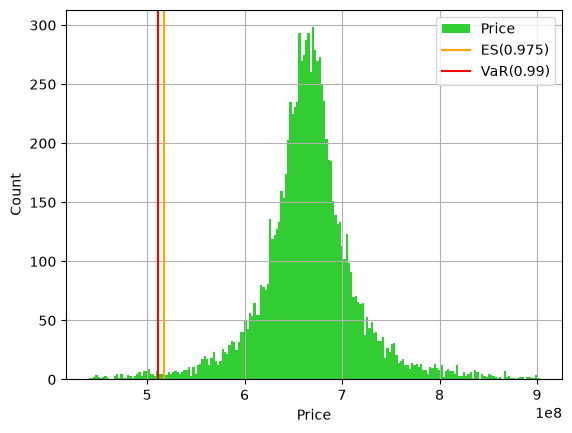

In [26]:
plt.hist(prices, bins=200, color='limegreen', label="Price")
plt.grid()

plt.axvline(x=es, color='orange', label="ES(0.975)")
plt.axvline(x=var, color='red', label="VaR(0.99)")

plt.xlabel("Price")
plt.ylabel("Count")

plt.legend()
plt.savefig("plots/prices-day1.png")
plt.show()

In [15]:
start_date = "2025-12-01" # базовая дата
end_date = "2025-12-10"

prices = price_samples(
    10_000, df_params, df_md, start_date=start_date, end_date=end_date, 
    ols_params=ols_params
)

In [18]:
prices = np.array(prices)

var = np.quantile(prices, q=0.01)
es = prices[prices < np.quantile(prices, 0.025)].mean()

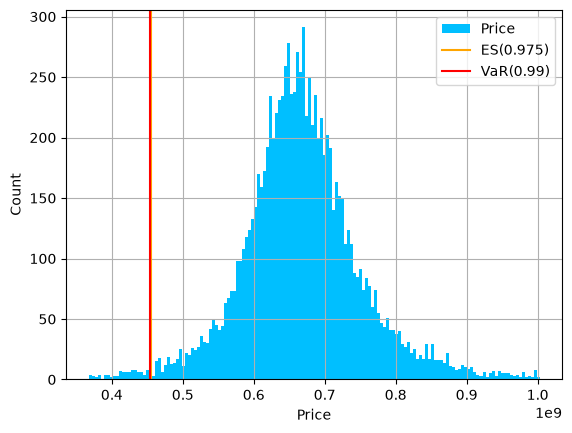

In [20]:
plt.hist(prices, bins=150, color='deepskyblue', label="Price")
plt.grid()

plt.axvline(x=es, color='orange', label="ES(0.975)")
plt.axvline(x=var, color='red', label="VaR(0.99)")

plt.xlabel("Price")
plt.ylabel("Count")

plt.legend()
plt.savefig("plots/prices-days10.png")
plt.show()